<a href="https://colab.research.google.com/github/Dnyamwamu/neural_nets/blob/main/Notebooks/Chap08/8_1_MNIST_1D_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 8.1: MNIST_1D_Performance**

This notebook runs a simple neural network on the MNIST1D dataset as in figure 8.2a. It uses code from https://github.com/greydanus/mnist1d to generate the data.

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.

In [1]:
# Run this if you're in a Colab to install MNIST 1D repository
%pip install git+https://github.com/greydanus/mnist1d

  Cloning https://github.com/greydanus/mnist1d to /tmp/pip-req-build-yqxin61c
  Running command git clone --filter=blob:none --quiet https://github.com/greydanus/mnist1d /tmp/pip-req-build-yqxin61c
  Resolved https://github.com/greydanus/mnist1d to commit 7878d96082abd200c546a07a4101fa90b30fdf7e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mnist1d: filename=mnist1d-0.0.2.post16-py3-none-any.whl size=14664 sha256=e800cb83dd67e6261ac53ad0bd2a4bd321286dd9c1ac5537ce54de0b78ec59ac
  Stored in directory: /tmp/pip-ephem-wheel-cache-2r37k78o/wheels/18/40/b6/29381fee9b4c80fdbc304d52bb065a7286bbcca5ca2b8737c0
Successfully built mnist1d


In [2]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
import numpy as np
import matplotlib.pyplot as plt
import mnist1d

Let's generate a training and test dataset using the MNIST1D code.  The dataset gets saved as a .pkl file so it doesn't have to be regenerated each time.

In [3]:
args = mnist1d.data.get_dataset_args()
data = mnist1d.data.get_dataset(args, path='./mnist1d_data.pkl', download=False, regenerate=False)

# The training and test input and outputs are in
# data['x'], data['y'], data['x_test'], and data['y_test']
print("Examples in training set: {}".format(len(data['y'])))
print("Examples in test set: {}".format(len(data['y_test'])))
print("Length of each example: {}".format(data['x'].shape[-1]))

Did or could not load data from ./mnist1d_data.pkl. Rebuilding dataset...
Examples in training set: 4000
Examples in test set: 1000
Length of each example: 40


In [4]:
D_i = 40    # Input dimensions
D_k = 100   # Hidden dimensions
D_o = 10    # Output dimensions
# TODO:
# Define a model with two hidden layers of size 100
# And ReLU activations between them
# Replace this line (see Figure 7.8 of book for help):
model = torch.nn.Sequential(
    nn.Linear(D_i, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_o)
)


def weights_init(layer_in):
    if isinstance(layer_in, nn.Linear):
        nn.init.kaiming_normal_(layer_in.weight, nonlinearity='relu')
        if layer_in.bias is not None:
            nn.init.zeros_(layer_in.bias)


# Call the function you just defined
model.apply(weights_init)


Sequential(
  (0): Linear(in_features=40, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=100, bias=True)
  (3): ReLU()
  (4): Linear(in_features=100, out_features=10, bias=True)
)

In [5]:
# choose cross entropy loss function (equation 5.24)
loss_function = torch.nn.CrossEntropyLoss()
# construct SGD optimizer and initialize learning rate and momentum
optimizer = torch.optim.SGD(model.parameters(), lr = 0.05, momentum=0.9)
# object that decreases learning rate by half every 10 epochs
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)
x_train = torch.tensor(data['x'].astype('float32'))
y_train = torch.tensor(data['y'].transpose().astype('int64'))
x_test= torch.tensor(data['x_test'].astype('float32'))
y_test = torch.tensor(data['y_test'].astype('int64'))

# load the data into a class that creates the batches
data_loader = DataLoader(TensorDataset(x_train,y_train), batch_size=100, shuffle=True, worker_init_fn=np.random.seed(1))

# Initialize model weights
model.apply(weights_init)

# loop over the dataset n_epoch times
n_epoch = 50
# store the loss and the % correct at each epoch
losses_train = np.zeros((n_epoch))
errors_train = np.zeros((n_epoch))
losses_test = np.zeros((n_epoch))
errors_test = np.zeros((n_epoch))

for epoch in range(n_epoch):
  # loop over batches
  for i, batch in enumerate(data_loader):
    # retrieve inputs and labels for this batch
    x_batch, y_batch = batch
    # zero the parameter gradients
    optimizer.zero_grad()
    # forward pass -- calculate model output
    pred = model(x_batch)
    # compute the loss
    loss = loss_function(pred, y_batch)
    # backward pass
    loss.backward()
    # SGD update
    optimizer.step()

  # Run whole dataset to get statistics -- normally wouldn't do this
  pred_train = model(x_train)
  pred_test = model(x_test)
  _, predicted_train_class = torch.max(pred_train.data, 1)
  _, predicted_test_class = torch.max(pred_test.data, 1)
  errors_train[epoch] = 100 - 100 * (predicted_train_class == y_train).float().sum() / len(y_train)
  errors_test[epoch]= 100 - 100 * (predicted_test_class == y_test).float().sum() / len(y_test)
  losses_train[epoch] = loss_function(pred_train, y_train).item()
  losses_test[epoch]= loss_function(pred_test, y_test).item()
  print(f'Epoch {epoch:5d}, train loss {losses_train[epoch]:.6f}, train error {errors_train[epoch]:3.2f},  test loss {losses_test[epoch]:.6f}, test error {errors_test[epoch]:3.2f}')

  # tell scheduler to consider updating learning rate
  scheduler.step()

Epoch     0, train loss 1.565416, train error 60.83,  test loss 1.656635, test error 66.70
Epoch     1, train loss 1.303914, train error 48.78,  test loss 1.454423, test error 57.20
Epoch     2, train loss 1.124442, train error 40.75,  test loss 1.333094, test error 51.30
Epoch     3, train loss 0.986529, train error 35.32,  test loss 1.225409, test error 47.70
Epoch     4, train loss 0.865597, train error 29.93,  test loss 1.133665, test error 44.30
Epoch     5, train loss 0.811788, train error 28.40,  test loss 1.181381, test error 44.40
Epoch     6, train loss 0.687452, train error 23.55,  test loss 1.106511, test error 41.50
Epoch     7, train loss 0.731066, train error 27.40,  test loss 1.286967, test error 46.20
Epoch     8, train loss 0.544421, train error 18.03,  test loss 1.084054, test error 40.50
Epoch     9, train loss 0.484881, train error 16.20,  test loss 1.105783, test error 40.40
Epoch    10, train loss 0.382126, train error 10.55,  test loss 1.016757, test error 38.50

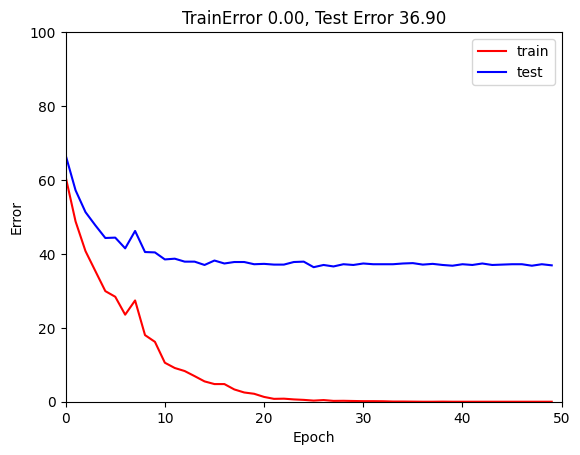

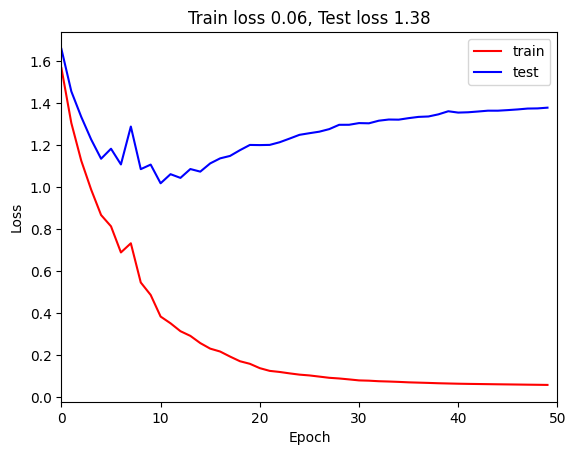

In [6]:
# Plot the results
fig, ax = plt.subplots()
ax.plot(errors_train,'r-',label='train')
ax.plot(errors_test,'b-',label='test')
ax.set_ylim(0,100); ax.set_xlim(0,n_epoch)
ax.set_xlabel('Epoch'); ax.set_ylabel('Error')
ax.set_title('TrainError %3.2f, Test Error %3.2f'%(errors_train[-1],errors_test[-1]))
ax.legend()
plt.show()

# Plot the results
fig, ax = plt.subplots()
ax.plot(losses_train,'r-',label='train')
ax.plot(losses_test,'b-',label='test')
ax.set_xlim(0,n_epoch)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Train loss %3.2f, Test loss %3.2f'%(losses_train[-1],losses_test[-1]))
ax.legend()
plt.show()

**TODO**

Play with the model -- try changing the number of layers, hidden units, learning rate, batch size, momentum or anything else you like.  See if you can improve the test results.

Is it a good idea to optimize the hyperparameters in this way?  Will the final result be a good estimate of the true test performance?

  Cloning https://github.com/greydanus/mnist1d to /tmp/pip-req-build-xnyu53e6
  Running command git clone --filter=blob:none --quiet https://github.com/greydanus/mnist1d /tmp/pip-req-build-xnyu53e6
  Resolved https://github.com/greydanus/mnist1d to commit 7878d96082abd200c546a07a4101fa90b30fdf7e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Successfully loaded data from ./mnist1d_data.pkl
Training examples: 4000
Test examples: 1000
Input length: 40
Epoch 1/30 | Train Error: 82.78% | Val Error: 76.12%
Epoch 2/30 | Train Error: 69.69% | Val Error: 69.75%
Epoch 3/30 | Train Error: 62.97% | Val Error: 68.00%
Epoch 4/30 | Train Error: 58.06% | Val Error: 63.12%
Epoch 5/30 | Train Error: 53.62% | Val Error: 60.38%
Epoch 6/30 | Train Error: 51.09% | Val Error: 60.38%
Epoch 7/30 | Train Error: 46.56% | Val Error: 58.62%
Epoch 8/30 | Train Error: 43.81% | Val Error: 58.00%
Epoch 9/30 | Train Error: 40.97% |

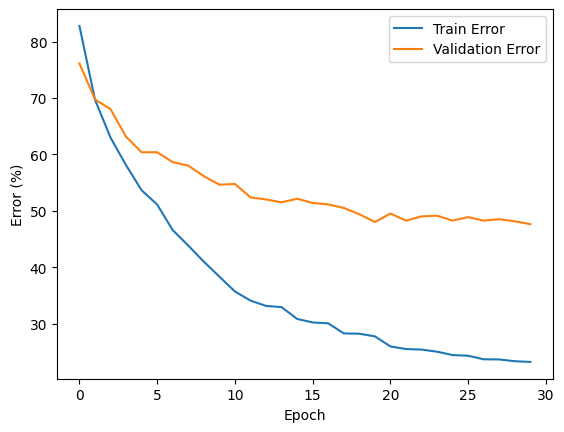

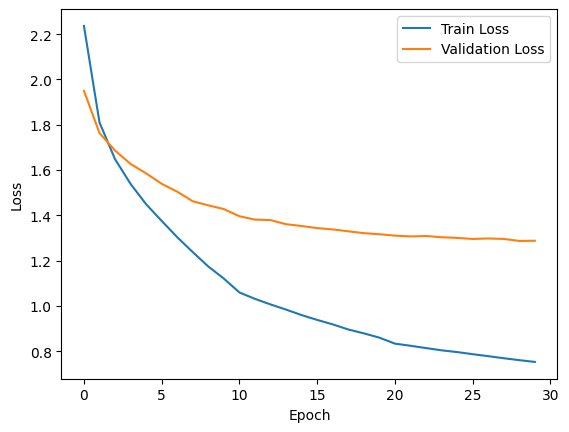

In [7]:
# Install MNIST1D
!pip install git+https://github.com/greydanus/mnist1d

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from torch.optim.lr_scheduler import StepLR
import numpy as np
import matplotlib.pyplot as plt
import mnist1d

# Load dataset
args = mnist1d.data.get_dataset_args()
data = mnist1d.data.get_dataset(args, path='./mnist1d_data.pkl', download=False, regenerate=False)

print("Training examples:", len(data['y']))
print("Test examples:", len(data['y_test']))
print("Input length:", data['x'].shape[-1])

# Convert to tensors
X = torch.tensor(data['x'], dtype=torch.float32)
y = torch.tensor(data['y'], dtype=torch.long)

X_test = torch.tensor(data['x_test'], dtype=torch.float32)
y_test = torch.tensor(data['y_test'], dtype=torch.long)

# Create validation split
dataset = TensorDataset(X, y)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

# DataLoaders
batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size)

# Network dimensions
D_i = 40
D_k = 100
D_o = 10

# Model with two hidden layers
model = nn.Sequential(
    nn.Linear(D_i, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_o)
)

# He initialization
def weights_init(layer):
    if isinstance(layer, nn.Linear):
        nn.init.kaiming_normal_(layer.weight)
        nn.init.zeros_(layer.bias)

model.apply(weights_init)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

# Training parameters
n_epoch = 30

train_losses = []
val_losses = []
train_errors = []
val_errors = []

for epoch in range(n_epoch):

    # ---- Training ----
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()

        outputs = model(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)

        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_losses.append(total_loss / len(train_loader))
    train_errors.append(100 * (1 - correct / total))

    # ---- Validation ----
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)

            val_loss += loss.item()
            preds = outputs.argmax(dim=1)

            correct += (preds == yb).sum().item()
            total += yb.size(0)

    val_losses.append(val_loss / len(val_loader))
    val_errors.append(100 * (1 - correct / total))

    scheduler.step()

    print(f"Epoch {epoch+1}/{n_epoch} | Train Error: {train_errors[-1]:.2f}% | Val Error: {val_errors[-1]:.2f}%")

# ---- Test evaluation ----
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

test_error = 100 * (1 - correct / total)
print("Final Test Error:", test_error)

# ---- Plot Errors ----
plt.plot(train_errors, label="Train Error")
plt.plot(val_errors, label="Validation Error")
plt.xlabel("Epoch")
plt.ylabel("Error (%)")
plt.legend()
plt.show()

# ---- Plot Loss ----
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()